## **Mounting**

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [7]:
import matplotlib
import sklearn
import imblearn
import torch

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)
print("torch:", torch.__version__)

numpy: 2.0.2
pandas: 2.2.2
matplotlib: 3.10.0
seaborn: 0.13.2
scikit-learn: 1.6.1
imbalanced-learn: 0.14.2
torch: 2.11.0+cpu


## **Dataset Info**

DATASET REPRESENTATION

Shape: 211043 rows x 44 columns

Column Data Types:
object     27
int64      16
float64     1
Name: count, dtype: int64

Feature List:
 - src_ip (object)
 - src_port (int64)
 - dst_ip (object)
 - dst_port (int64)
 - proto (object)
 - service (object)
 - duration (float64)
 - src_bytes (int64)
 - dst_bytes (int64)
 - conn_state (object)
 - missed_bytes (int64)
 - src_pkts (int64)
 - src_ip_bytes (int64)
 - dst_pkts (int64)
 - dst_ip_bytes (int64)
 - dns_query (object)
 - dns_qclass (int64)
 - dns_qtype (int64)
 - dns_rcode (int64)
 - dns_AA (object)
 - dns_RD (object)
 - dns_RA (object)
 - dns_rejected (object)
 - ssl_version (object)
 - ssl_cipher (object)
 - ssl_resumed (object)
 - ssl_established (object)
 - ssl_subject (object)
 - ssl_issuer (object)
 - http_trans_depth (object)
 - http_method (object)
 - http_uri (object)
 - http_version (object)
 - http_request_body_len (int64)
 - http_response_body_len (int64)
 - http_status_code (int64)
 - http_user_agent

,count,mean,std,min,25%,50%,75%,max
src_port,211043.0,38646.519543,1.930727e+04,1.0,34608.0,44754.00000,51133.000000,6.552800e+04
dst_port,211043.0,3495.153770,1.019162e+04,0.0,65.0,80.00000,1253.000000,6.546700e+04
duration,211043.0,7.700887,5.641419e+02,0.0,0.0,0.00017,0.054196,9.351693e+04
src_bytes,211043.0,258113.564274,1.709490e+07,0.0,0.0,0.00000,130.000000,3.890855e+09
dst_bytes,211043.0,258804.571575,1.802563e+07,0.0,0.0,0.00000,89.000000,3.913853e+09
missed_bytes,211043.0,34432.344295,5.261621e+06,0.0,0.0,0.00000,0.000000,1.854527e+09
src_pkts,211043.0,9.595220,9.177882e+01,0.0,1.0,1.00000,4.000000,2.462300e+04
src_ip_bytes,211043.0,776.082206,2.229703e+04,0.0,48.0,82.00000,415.000000,6.522626e+06
dst_pkts,211043.0,3.846861,3.307058e+02,0.0,0.0,1.00000,2.000000,1.219420e+05
dst_ip_bytes,211043.0,1584.686628,1.901795e+05,0.0,0.0,40.00000,134.000000,8.639552e+07



Categorical Feature Summary:


,count,unique,top,freq
src_ip,211043,51,192.168.1.30,61633
dst_ip,211043,753,192.168.1.190,47795
proto,211043,3,tcp,168747
service,211043,9,-,132032
conn_state,211043,13,S0,51937
dns_query,211043,726,-,176198
dns_AA,211043,3,-,176030
dns_RD,211043,3,-,176030
dns_RA,211043,3,-,176030
dns_rejected,211043,3,-,176030



Target Distribution ('type'):
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64

Target Distribution ('label'):
label
1    161043
0     50000
Name: count, dtype: int64

Missing Values per Column:
No missing values.

Duplicate Rows: 20569


/tmp/ipykernel_3129/4279094867.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


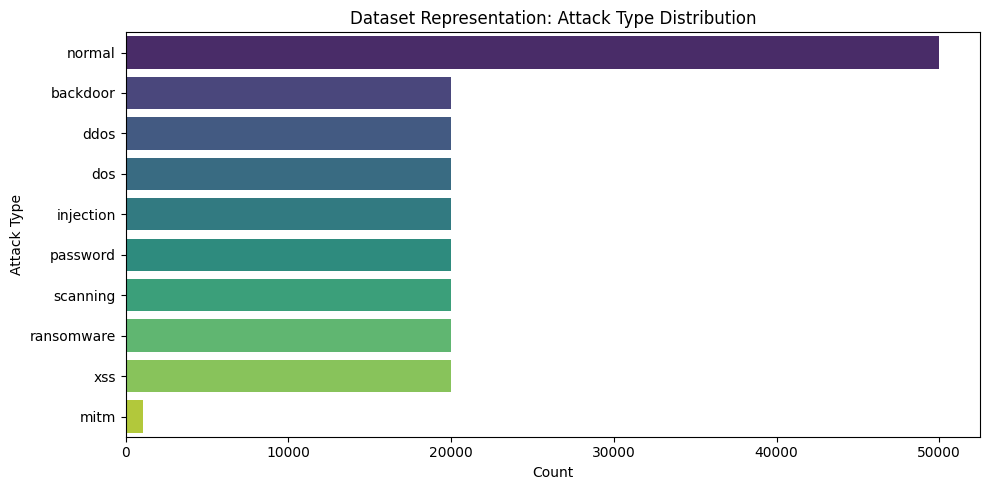

In [8]:
import pandas as pd

data_path = "/content/drive/MyDrive/CSFINALE/train_test_network(in).csv"

print("=" * 60)
print("DATASET REPRESENTATION")
print("=" * 60)

df = pd.read_csv(data_path)

print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns\n")

print("Column Data Types:")
print(df.dtypes.value_counts())

print("\nFeature List:")
for col in df.columns:
    print(f" - {col} ({df[col].dtype})")

print("\nNumerical Feature Summary:")
display(df.describe().T)

print("\nCategorical Feature Summary:")
display(df.describe(include=["object"]).T)

print("\nTarget Distribution ('type'):")
print(df["type"].value_counts())
print("\nTarget Distribution ('label'):")
print(df["label"].value_counts())

print("\nMissing Values per Column:")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No missing values.")

print("\nDuplicate Rows:", df.duplicated().sum())

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    y="type",
    order=df["type"].value_counts().index,
    palette="viridis"
)
plt.title("Dataset Representation: Attack Type Distribution")
plt.xlabel("Count")
plt.ylabel("Attack Type")
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(data_path), "dataset_type_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

# **Handle Missing value and Duplicate rows**

In [9]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

missing = df.isnull().sum()
print(missing[missing > 0])

df = df.dropna()
print("Shape after dropping missing values:", df.shape)

# FIX: covers both possible column naming conventions for this dataset
drop_columns = [
    "src_ip", "dst_ip", "ts",
    "id.orig_h", "id.resp_h", "uid"
]
existing = [c for c in drop_columns if c in df.columns]
df.drop(columns=existing, inplace=True)

print("Shape after dropping identifier columns:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  211043 non-null  object 
 1   src_port                211043 non-null  int64  
 2   dst_ip                  211043 non-null  object 
 3   dst_port                211043 non-null  int64  
 4   proto                   211043 non-null  object 
 5   service                 211043 non-null  object 
 6   duration                211043 non-null  float64
 7   src_bytes               211043 non-null  int64  
 8   dst_bytes               211043 non-null  int64  
 9   conn_state              211043 non-null  object 
 10  missed_bytes            211043 non-null  int64  
 11  src_pkts                211043 non-null  int64  
 12  src_ip_bytes            211043 non-null  int64  
 13  dst_pkts                211043 non-null  int64  
 14  dst_ip_bytes        

## **Categorical Columns**

In [10]:
categorical_cols = df.select_dtypes(include=["object"]).columns

print(categorical_cols)

Index(['proto', 'service', 'conn_state', 'dns_query', 'dns_AA', 'dns_RD',
       'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed',
       'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth',
       'http_method', 'http_uri', 'http_version', 'http_user_agent',
       'http_orig_mime_types', 'http_resp_mime_types', 'weird_name',
       'weird_addl', 'weird_notice', 'type'],
      dtype='object')


## **Encode Categorical Features**

In [11]:
label_encoders = {}

for col in categorical_cols:
    if col not in ["label", "type"]:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

print("Categorical Encoding Completed.")

Categorical Encoding Completed.


## **LOCO Split**

In [12]:
#Set zero-day attack for LOCO, ddos first, then ransomware
zero_day_attack = "ransomware"

test_df = df[df["type"] == zero_day_attack]

df = df[df["type"] != zero_day_attack]

print(test_df.shape)

print(df.shape)

(14735, 42)
(175739, 42)


## **Separate Label**

In [13]:
y = df["type"]
X = df.drop(columns=["label", "type"])

attack_encoder = LabelEncoder()
y_encoded = attack_encoder.fit_transform(y)

print("Classes:", list(attack_encoder.classes_))

Classes: ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'scanning', 'xss']


## **Train-test Split**

In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Zero-day holdout: evaluated using binary 'label', since this attack
# type was never seen during training and has no class in attack_encoder.
X_zd = test_df.drop(columns=["label", "type"])
y_zd = test_df["label"]

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Zero-day:", X_zd.shape)

Training: (140591, 40)
Validation: (35148, 40)
Zero-day: (14735, 40)


## **Scaling (Normalization)**

In [15]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val), columns=X.columns)
X_zd_scaled    = pd.DataFrame(scaler.transform(X_zd), columns=X.columns)

*   duplicates removed
*   missing values handled
*   categorical features encoded
*   numerical features standardized

In [16]:
save_dir = os.path.dirname(data_path)

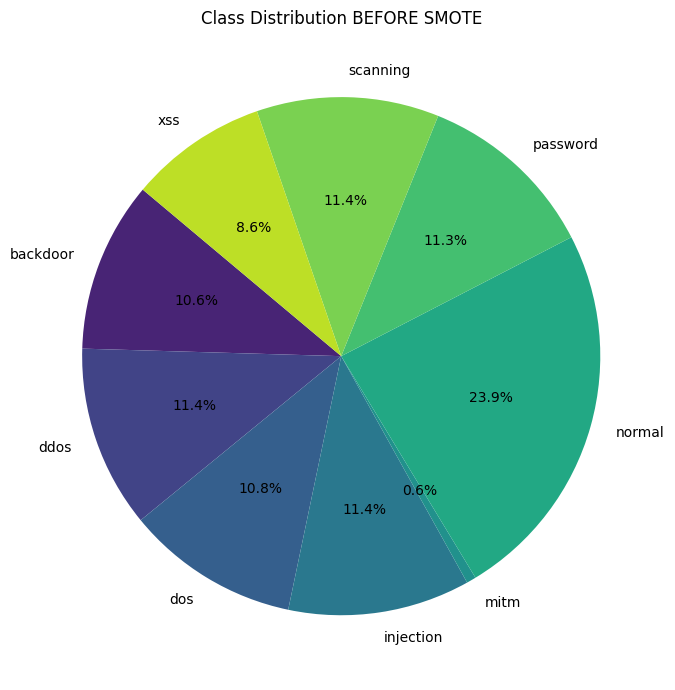

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import os
from google.colab import files

before_counts = pd.Series(y_train).value_counts().sort_index()
before_labels = attack_encoder.inverse_transform(before_counts.index)

plt.figure(figsize=(7, 7))
plt.pie(
    before_counts.values,
    labels=before_labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("viridis", len(before_counts))
)
plt.title("Class Distribution BEFORE SMOTE")
plt.tight_layout()

plot_path = os.path.join(save_dir, "class_distribution_before_smote.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
files.download(plot_path)

In [18]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Training shape after SMOTE:", X_train_resampled.shape)
print(pd.Series(y_train_resampled).value_counts())

Training shape after SMOTE: (302688, 40)
0    33632
2    33632
5    33632
8    33632
6    33632
7    33632
1    33632
3    33632
4    33632
Name: count, dtype: int64


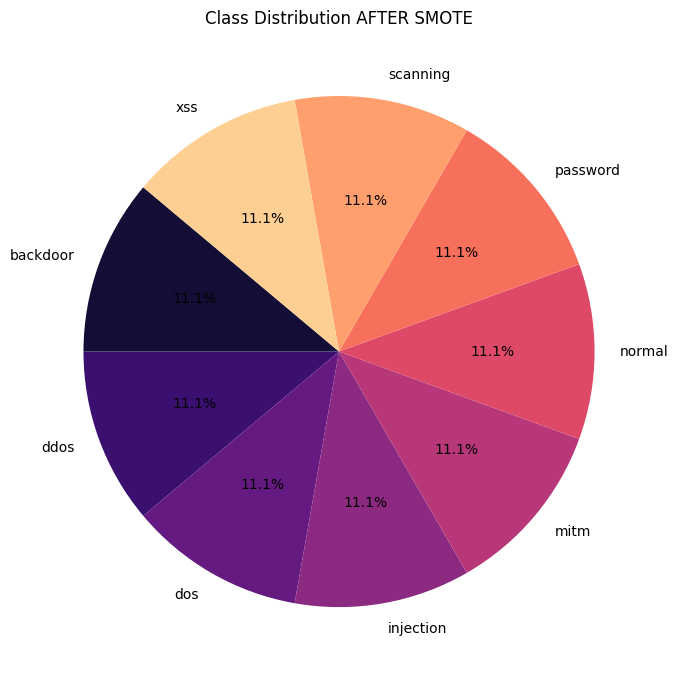

In [19]:
from google.colab import files

after_counts = pd.Series(y_train_resampled).value_counts().sort_index()
after_labels = attack_encoder.inverse_transform(after_counts.index)

plt.figure(figsize=(7, 7))
plt.pie(
    after_counts.values,
    labels=after_labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("magma", len(after_counts))
)
plt.title("Class Distribution AFTER SMOTE")
plt.tight_layout()

plot_path = os.path.join(save_dir, "class_distribution_after_smote.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
#files.download(plot_path)

In [20]:
# train/val: multiclass 'type' target (decoded back to attack names)
train_final = X_train_resampled.copy()
train_final["type"] = attack_encoder.inverse_transform(y_train_resampled)
train_final["split"] = "train"

val_final = X_val_scaled.copy()
val_final["type"] = attack_encoder.inverse_transform(y_val)
val_final["split"] = "val"

# zero_day: binary 'label' target, since this attack type has no
# class in attack_encoder (it was never seen during training)
zd_final = X_zd_scaled.copy()
zd_final["label"] = y_zd.values
zd_final["split"] = "zero_day"

combined = pd.concat([train_final, val_final, zd_final], ignore_index=True)

print(combined.shape)
print(combined["split"].value_counts())
combined.head()

(352571, 43)
split
train       302688
val          35148
zero_day     14735
Name: count, dtype: int64


,src_port,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,...,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,type,split,label
0,0.495195,-0.299039,-0.543413,-0.762682,-0.014057,-0.016153,-0.016318,-1.477300,-0.007247,-0.101053,...,-0.040218,-0.033459,-0.009148,-0.031288,-0.03654,-0.029715,-0.045543,backdoor,train,NaN
1,-2.055838,-0.298569,-0.543413,-0.762682,-0.014058,-0.016153,-0.016318,-1.477300,-0.007247,-0.101053,...,-0.040218,-0.033459,-0.009148,-0.031288,-0.03654,-0.029715,-0.045543,dos,train,NaN
2,-2.055993,-0.010420,-0.543413,-0.762682,-0.013693,-0.016153,-0.016318,-0.105486,-0.007247,1.063035,...,-0.040218,-0.033459,-0.009148,-0.031288,-0.03654,-0.029715,-0.045543,normal,train,NaN
3,0.453430,-0.299039,-0.543413,1.686693,0.003233,-0.016058,-0.016259,0.717602,-0.007247,-0.052142,...,-0.040218,-0.033459,-0.009148,-0.031288,-0.03654,-0.029715,-0.045543,xss,train,NaN
4,1.011814,-0.299039,-0.543413,1.686693,0.194390,-0.016060,-0.016139,-0.654212,-0.007247,-0.061924,...,-0.040218,-0.033459,-0.009148,-0.031288,-0.03654,-0.029715,-0.045543,xss,train,NaN


In [21]:
# Save in the exact same directory as the original dataset file
output_path = os.path.join(save_dir, "preprocessed_full_ttn.csv")

combined.to_csv(output_path, index=False)

print(f"Preprocessed dataset saved to: {output_path}")

Preprocessed dataset saved to: /content/drive/MyDrive/CSFINALE/preprocessed_full_ttn.csv


# K-Means

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances

In [23]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 11)

# Check size first (just informational)
print("Training data shape:", X_train_resampled.shape)

for k in K_range:
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        batch_size=1000
    )

    cluster_labels = kmeans.fit_predict(X_train_resampled)

    score = silhouette_score(
        X_train_resampled,
        cluster_labels,
        sample_size=5000,   # estimate on a random sample instead of all rows
        random_state=42
    )

    silhouette_scores.append(score)
    print(f"K = {k} | Silhouette Score = {score:.4f}")

Training data shape: (302688, 40)
K = 2 | Silhouette Score = 0.5584
K = 3 | Silhouette Score = 0.4283
K = 4 | Silhouette Score = 0.4661
K = 5 | Silhouette Score = 0.4637
K = 6 | Silhouette Score = 0.3785
K = 7 | Silhouette Score = 0.3383
K = 8 | Silhouette Score = 0.4523
K = 9 | Silhouette Score = 0.4303
K = 10 | Silhouette Score = 0.4920


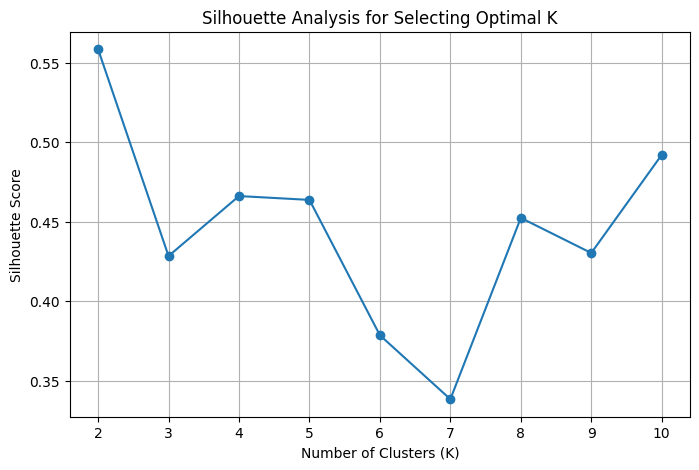

In [24]:
from google.colab import files
import os

plt.figure(figsize=(8,5))

plt.plot(
    K_range,
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Selecting Optimal K")

plt.grid(True)

# Define the path to save the plot
plot_path = os.path.join(save_dir, "silhouette_analysis.png")

# Save the plot to the specified path
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

plt.show()

# Provide a download link for the saved plot
#files.download(plot_path)

In [25]:
best_k = K_range[np.argmax(silhouette_scores)]

print("Optimal K:", best_k)

Optimal K: 2


In [26]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

train_clusters = kmeans.fit_predict(X_train_resampled)

print("K-Means training completed.")

K-Means training completed.


In [27]:
centroids = kmeans.cluster_centers_

print("Centroid Shape:", centroids.shape)

centroids

Centroid Shape: (2, 40)


array([[ 7.01187878e-02, -4.49193411e-02, -8.73347766e-02,
         9.92097522e-02,  3.48313154e-03,  2.85805232e-04,
         1.42538662e-04,  5.33952781e-02, -2.29912965e-03,
        -1.33551863e-02,  9.34861478e-03,  1.69746840e-02,
         4.55339941e-03,  3.98604557e-02, -4.84594080e-02,
        -7.97067149e-02, -4.68798141e-02, -4.07039052e-02,
        -7.89892859e-03,  9.13758892e-02, -2.66255240e-02,
        -2.53369516e-02, -2.33556387e-02, -2.43795443e-02,
        -2.43395281e-02, -3.23566229e-03, -3.04856432e-03,
        -1.49437220e-02, -1.69116785e-02, -1.77776572e-02,
        -1.90348125e-02, -4.22985677e-03, -5.74733443e-03,
        -1.77886447e-02, -1.38074962e-02, -4.89839396e-03,
        -1.23265028e-02, -1.92886948e-02, -1.59111737e-02,
        -2.42625652e-02],
       [-1.69246620e+00, -3.10033102e-01, -2.25674798e+00,
        -6.28039785e-01,  2.06942580e-01,  1.81539158e-01,
        -1.57854475e-02, -1.37461850e+00, -7.24708379e-03,
         1.54476239e+02,  1.67

In [28]:
distances = pairwise_distances(
    X_train_resampled,
    centroids
)

nearest_distance = np.min(
    distances,
    axis=1
)

In [29]:
kmeans_results = X_train_resampled.copy()

kmeans_results["Nearest_Distance"] = nearest_distance

kmeans_results["Cluster"] = train_clusters

kmeans_results.head()

,src_port,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,Nearest_Distance,Cluster
0,0.495195,-0.299039,-0.543413,-0.762682,-0.014057,-0.016153,-0.016318,-1.477300,-0.007247,-0.101053,...,-0.010774,-0.040218,-0.033459,-0.009148,-0.031288,-0.03654,-0.029715,-0.045543,2.160001,0
1,-2.055838,-0.298569,-0.543413,-0.762682,-0.014058,-0.016153,-0.016318,-1.477300,-0.007247,-0.101053,...,-0.010774,-0.040218,-0.033459,-0.009148,-0.031288,-0.03654,-0.029715,-0.045543,3.000732,0
2,-2.055993,-0.010420,-0.543413,-0.762682,-0.013693,-0.016153,-0.016318,-0.105486,-0.007247,1.063035,...,-0.010774,-0.040218,-0.033459,-0.009148,-0.031288,-0.03654,-0.029715,-0.045543,2.791954,0
3,0.453430,-0.299039,-0.543413,1.686693,0.003233,-0.016058,-0.016259,0.717602,-0.007247,-0.052142,...,-0.010774,-0.040218,-0.033459,-0.009148,-0.031288,-0.03654,-0.029715,-0.045543,2.121250,0
4,1.011814,-0.299039,-0.543413,1.686693,0.194390,-0.016060,-0.016139,-0.654212,-0.007247,-0.061924,...,-0.010774,-0.040218,-0.033459,-0.009148,-0.031288,-0.03654,-0.029715,-0.045543,2.309920,0


In [30]:
d_min = 2.0

kmeans_results["Outlier"] = (
    kmeans_results["Nearest_Distance"] > d_min
)

kmeans_results["Outlier"].value_counts()

,count
Outlier,
True,236643
False,66045


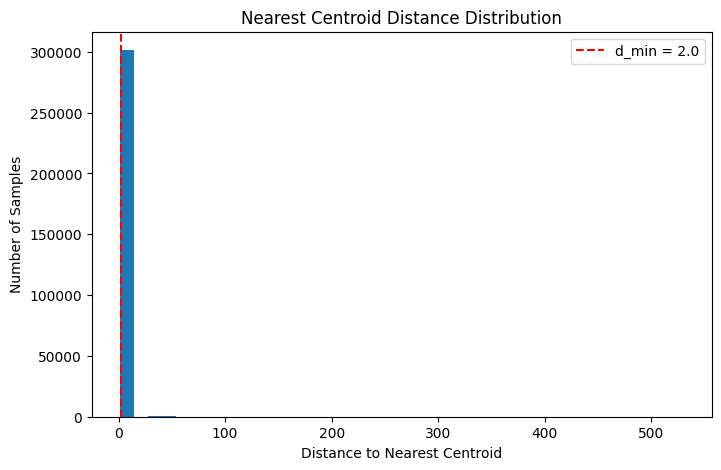

In [31]:
plt.figure(figsize=(8,5))

plt.hist(
    kmeans_results["Nearest_Distance"],
    bins=40
)

plt.axvline(
    d_min,
    color='red',
    linestyle='--',
    label=f'd_min = {d_min}'
)

plt.xlabel("Distance to Nearest Centroid")
plt.ylabel("Number of Samples")
plt.title("Nearest Centroid Distance Distribution")

plt.legend()

plot_path = os.path.join(save_dir, "nearest_centroid_distance_distribution.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
#files.download(plot_path)

In [32]:
kmeans_results.to_csv(
    os.path.join(save_dir, "kmeans_results.csv"),
    index=False
)

print("K-Means results saved successfully.")

K-Means results saved successfully.


In [33]:

# Compute distance from each validation sample to every centroid

val_distances = pairwise_distances(
    X_val_scaled,
    centroids
)

val_nearest_distance = np.min(
    val_distances,
    axis=1
)

In [34]:
val_results = X_val_scaled.copy()

val_results["Nearest_Distance"] = val_nearest_distance

val_results["Outlier"] = (
    val_results["Nearest_Distance"] > d_min
)

print(val_results["Outlier"].value_counts())

Outlier
True     28024
False     7124
Name: count, dtype: int64


In [35]:
zd_distances = pairwise_distances(
    X_zd_scaled,
    centroids
)

zd_nearest_distance = np.min(
    zd_distances,
    axis=1
)

In [36]:
zero_day_results = X_zd_scaled.copy()

zero_day_results["Nearest_Distance"] = zd_nearest_distance

zero_day_results["Outlier"] = (
    zero_day_results["Nearest_Distance"] > d_min
)

print(zero_day_results["Outlier"].value_counts())

Outlier
True     10737
False     3998
Name: count, dtype: int64


In [37]:
zdr = zero_day_results["Outlier"].mean()

print(f"Zero-Day Detection Rate (Z-DR): {zdr:.4f}")
print(f"Zero-Day Detection Rate (%): {zdr*100:.2f}%")

Zero-Day Detection Rate (Z-DR): 0.7287
Zero-Day Detection Rate (%): 72.87%


In [38]:
false_positive_rate = val_results["Outlier"].mean()

print(f"False Positive Rate (FPR): {false_positive_rate:.4f}")
print(f"False Positive Rate (%): {false_positive_rate*100:.2f}%")

False Positive Rate (FPR): 0.7973
False Positive Rate (%): 79.73%


In [39]:
val_results.to_csv(
    os.path.join(save_dir, "validation_kmeans_results.csv"),
    index=False
)

zero_day_results.to_csv(
    os.path.join(save_dir, "zero_day_kmeans_results.csv"),
    index=False
)

print("Validation and Zero-Day results saved successfully.")

Validation and Zero-Day results saved successfully.


# **Train model**

In [41]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Reshape to 3D tensors for RNN input
X_tr = torch.tensor(X_train_resampled.values, dtype=torch.float32).unsqueeze(1)
y_tr = torch.tensor(y_train_resampled, dtype=torch.long)
X_v  = torch.tensor(X_val_scaled.values, dtype=torch.float32).unsqueeze(1)
y_v  = torch.tensor(y_val, dtype=torch.long)

#define model parameters: the inputs, number of attack types, and size of hidden state in GRU
n_features  = X_tr.shape[2]   # 40
n_classes   = len(attack_encoder.classes_)  # 9
hidden_size = 64

class ABiGRU(nn.Module):
  #initialise and construct the model with attention and fully connected layers
    def __init__(self, input_size, hidden_size, n_classes):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size,
                          batch_first=True, bidirectional=True)
        # Attention
        self.attn = nn.Linear(hidden_size * 2, 1)
        self.fc   = nn.Linear(hidden_size * 2, n_classes)
  #define forward propagation of input, x, through the GRU
    def forward(self, x):
        out, _ = self.gru(x)              # (batch, 1, hidden*2)
        weights = torch.softmax(self.attn(out), dim=1)
        context = (weights * out).sum(dim=1)  # (batch, hidden*2)
        return self.fc(context)

#initialise model, optimiser and loss function
model     = ABiGRU(n_features, hidden_size, n_classes)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

#load dataloader for creating training batches
train_loader = DataLoader(TensorDataset(X_tr, y_tr),
                          batch_size=512, shuffle=True)

#maximum epochs is 20, stop when 3 consecutive epochs doesnt improve F1 score
EPOCHS, PATIENCE = 20, 3
best_val_f1, no_improve = 0, 0

#start training loop
for epoch in range(EPOCHS):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        criterion(model(xb), yb).backward()
        optimizer.step()

    # Validation F1
    #set the model to evaluation mode, no dropouts or updates
    model.eval()
    with torch.no_grad():
      #without gradient calculation, predictions are made from the feature tensor
        logits = model(X_v)
        preds  = logits.argmax(dim=1).numpy()
    from sklearn.metrics import f1_score
    #calculate F1 scores and compare if training should be stopped
    val_f1 = f1_score(y_v.numpy(), preds, average="macro")
    print(f"Epoch {epoch+1}: val macro-F1 = {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), f"{save_dir}/abigru_best.pt")
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print("Early stop.")
            break

# Reload best weights and freeze model
model.load_state_dict(torch.load(f"{save_dir}/abigru_best.pt"))
model.eval()
for p in model.parameters():
    p.requires_grad_(False)
print("Base classifier ready.")

Epoch 1: val macro-F1 = 0.6552
Epoch 2: val macro-F1 = 0.7534
Epoch 3: val macro-F1 = 0.7664
Epoch 4: val macro-F1 = 0.7970
Epoch 5: val macro-F1 = 0.8121
Epoch 6: val macro-F1 = 0.8202
Epoch 7: val macro-F1 = 0.8292
Epoch 8: val macro-F1 = 0.8336
Epoch 9: val macro-F1 = 0.8356
Epoch 10: val macro-F1 = 0.8370
Epoch 11: val macro-F1 = 0.8435
Epoch 12: val macro-F1 = 0.8409
Epoch 13: val macro-F1 = 0.8507
Epoch 14: val macro-F1 = 0.8530
Epoch 15: val macro-F1 = 0.8590
Epoch 16: val macro-F1 = 0.8615
Epoch 17: val macro-F1 = 0.8624
Epoch 18: val macro-F1 = 0.8614
Epoch 19: val macro-F1 = 0.8665
Epoch 20: val macro-F1 = 0.8713
Base classifier ready.


# **Baseline Evaluation on known data**

In [42]:
from sklearn.metrics import classification_report

#set mode to evaluation again
model.eval()
with torch.no_grad():
    #predict on Validation data
    logits = model(X_v)
    preds = logits.argmax(dim=1).numpy()

print(classification_report(
    y_val,
    preds,
    target_names=attack_encoder.classes_
))

              precision    recall  f1-score   support

    backdoor       0.95      1.00      0.97      3742
        ddos       0.96      0.92      0.94      3999
         dos       1.00      0.94      0.97      3799
   injection       0.92      0.84      0.88      3993
        mitm       0.23      0.90      0.37       208
      normal       1.00      0.98      0.99      8408
    password       0.90      0.91      0.91      3972
    scanning       0.96      0.93      0.94      4000
         xss       0.86      0.90      0.88      3027

    accuracy                           0.93     35148
   macro avg       0.86      0.92      0.87     35148
weighted avg       0.95      0.93      0.94     35148



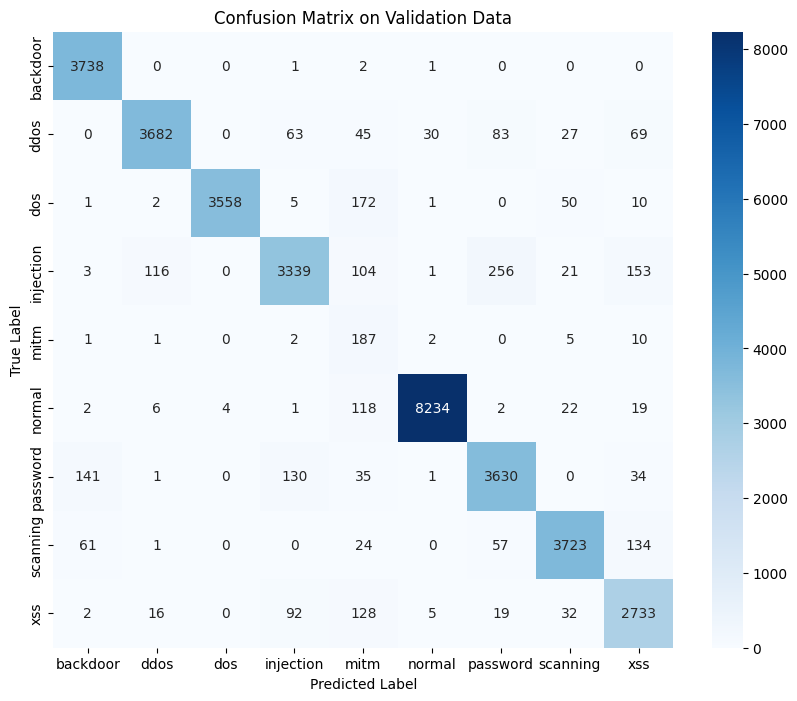

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#confusion matrix on validation data
cm = confusion_matrix(y_val, preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=attack_encoder.classes_,
            yticklabels=attack_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Validation Data')

plot_path = os.path.join(save_dir, "confusion_matrix_validation_data.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
#files.download(plot_path)

# **Evaluation on zero-day data**

In [44]:
from sklearn.metrics import pairwise_distances

#tensor signal for the base classifier
X_zd_tensor = torch.tensor(X_zd_scaled.values, dtype=torch.float32).unsqueeze(1)

#evaluate mode for test data
model.eval()
with torch.no_grad():
    zd_logits = model(X_zd_tensor)
    zd_probs = torch.softmax(zd_logits, dim=1).numpy()
    # Maximum probability across the known classes
    zd_confidence = zd_probs.max(axis=1)

# evaluate K-Means distance signal
zd_distances = pairwise_distances(X_zd_scaled.values, centroids)
zd_nearest_dist = zd_distances.min(axis=1)

#Combine signals: flag as zero-day if distance > d_min
zd_flagged = zd_nearest_dist > d_min

# calculate Z-DR(fraction of zero-day pool correctly flagged)
Z_DR = zd_flagged.sum() / len(zd_flagged)
print(f"Z-DR at d_min={d_min}: {Z_DR:.4f}")

# calculate FPR(normal flows from val set incorrectly flagged)
# Isolate normal flows from validation label
normal_mask = (y_val == attack_encoder.transform(["normal"])[0])

#Extract features with normal flows
X_normal = X_val_scaled.values[normal_mask]
normal_distances = pairwise_distances(X_normal, centroids).min(axis=1)
FPR = (normal_distances > d_min).sum() / len(normal_distances)
print(f"FPR at d_min={d_min}: {FPR:.4f}")

Z-DR at d_min=2.0: 0.7287
FPR at d_min=2.0: 0.9977


# **Parameter Sweep**

In [45]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import pairwise_distances
import pandas as pd
import numpy as np

K_values     = [2, 3, 5, 7, 9]
d_min_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]

# Normal flows from validation set (for FPR)
normal_class_idx = attack_encoder.transform(["normal"])[0]
normal_mask = (y_val == normal_class_idx)
X_normal = X_val_scaled.values[normal_mask]

results = []

for k in K_values:
    print(f"\nFitting MiniBatchKMeans with K={k}...")
    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        batch_size=1000
    )
    km.fit(X_train_resampled)
    cents = km.cluster_centers_

    zd_dists     = pairwise_distances(X_zd_scaled.values, cents).min(axis=1)
    normal_dists = pairwise_distances(X_normal, cents).min(axis=1)

    for d in d_min_values:
        zdr = (zd_dists > d).sum() / len(zd_dists)
        fpr = (normal_dists > d).sum() / len(normal_dists)
        precision = 1 - fpr
        recall    = zdr
        f1 = (2 * precision * recall / (precision + recall + 1e-9))

        results.append({
            "K":     k,
            "d_min": d,
            "Z_DR":  round(float(zdr), 4),
            "FPR":   round(float(fpr), 4),
            "F1":    round(float(f1),  4)
        })

    print(f"  K={k} done.")

sweep_df = pd.DataFrame(results)
sweep_df.to_csv(f"{save_dir}/k_dmin_sweep.csv", index=False)
print("\nFull sweep complete.")
print(sweep_df.to_string(index=False))


Fitting MiniBatchKMeans with K=2...
  K=2 done.

Fitting MiniBatchKMeans with K=3...
  K=3 done.

Fitting MiniBatchKMeans with K=5...
  K=5 done.

Fitting MiniBatchKMeans with K=7...
  K=7 done.

Fitting MiniBatchKMeans with K=9...
  K=9 done.

Full sweep complete.
 K  d_min   Z_DR    FPR     F1
 2    0.5 1.0000 1.0000 0.0000
 2    1.0 0.8206 0.9994 0.0012
 2    1.5 0.8166 0.9979 0.0043
 2    2.0 0.0938 0.9762 0.0379
 2    2.5 0.0637 0.4459 0.1143
 2    3.0 0.0632 0.3108 0.1158
 2    4.0 0.0629 0.1254 0.1174
 2    5.0 0.0629 0.1194 0.1174
 3    0.5 0.9501 0.9995 0.0010
 3    1.0 0.8174 0.9956 0.0088
 3    1.5 0.1869 0.9932 0.0131
 3    2.0 0.0818 0.9339 0.0731
 3    2.5 0.0637 0.4353 0.1145
 3    3.0 0.0632 0.2895 0.1160
 3    4.0 0.0629 0.1252 0.1174
 3    5.0 0.0629 0.1194 0.1174
 5    0.5 1.0000 0.9838 0.0318
 5    1.0 0.8174 0.9713 0.0554
 5    1.5 0.1697 0.9697 0.0515
 5    2.0 0.1084 0.9125 0.0969
 5    2.5 0.0637 0.4368 0.1145
 5    3.0 0.0632 0.2657 0.1164
 5    4.0 0.0629 0.0

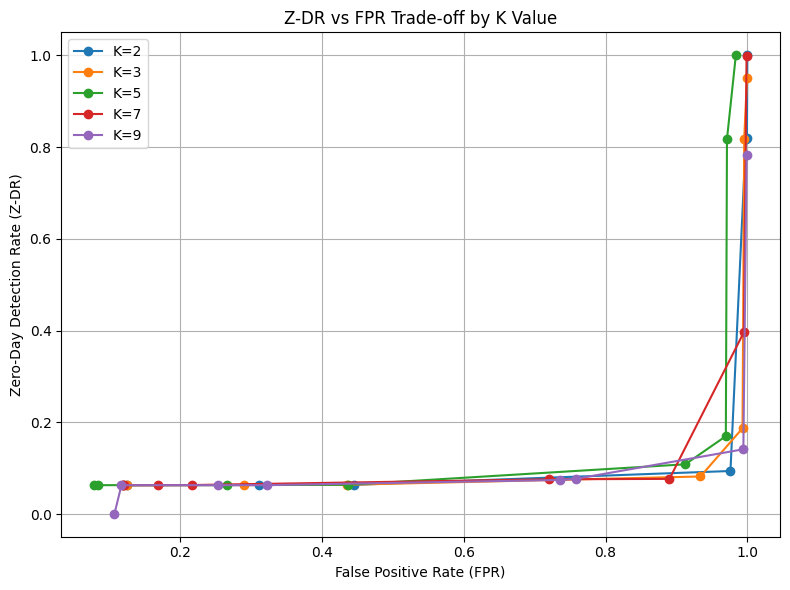

In [51]:
fig, ax = plt.subplots(figsize=(8, 6))

for k in K_values:
    subset = sweep_df[sweep_df["K"] == k]
    ax.plot(subset["FPR"], subset["Z_DR"],
            marker="o", label=f"K={k}")

ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("Zero-Day Detection Rate (Z-DR)")
ax.set_title("Z-DR vs FPR Trade-off by K Value")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(f"{save_dir}/zdr_fpr_tradeoff.png", dpi=300)
plt.show()

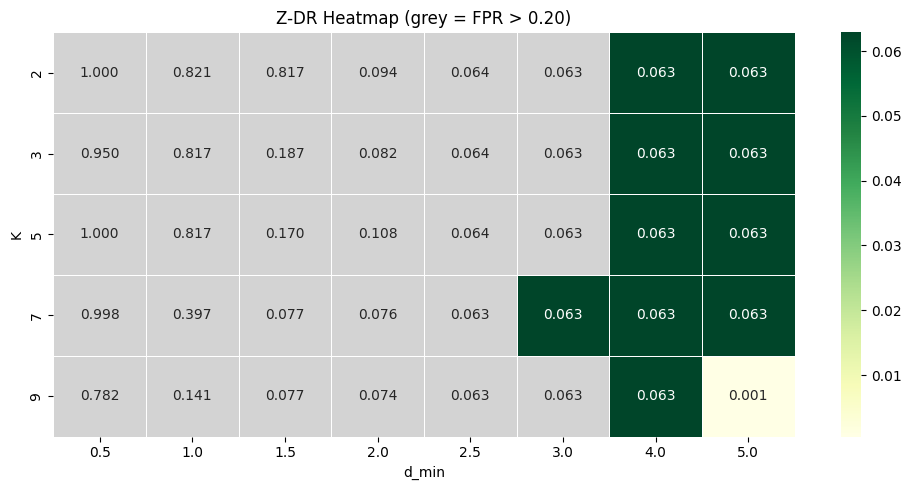

In [50]:
pivot_zdr = sweep_df.pivot(index="K", columns="d_min", values="Z_DR")
pivot_fpr = sweep_df.pivot(index="K", columns="d_min", values="FPR")

# Mask cells where FPR > 0.20 (unacceptable false alarm rate)
mask = pivot_fpr > 0.20

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot_zdr,
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="YlGn",
    ax=ax,
    linewidths=0.5
)
# Overlay greyed-out cells for masked region
sns.heatmap(
    pivot_zdr,
    mask=~mask,
    annot=True,
    fmt=".3f",
    cmap=["#d3d3d3"],
    ax=ax,
    cbar=False,
    linewidths=0.5
)
ax.set_title("Z-DR Heatmap (grey = FPR > 0.20)")
ax.set_xlabel("d_min")
ax.set_ylabel("K")
plt.tight_layout()
plt.savefig(f"{save_dir}/zdr_heatmap.png", dpi=300)
plt.show()

In [49]:
# Pivot F1 scores into Kxd_min table
pivot_f1 = sweep_df.pivot(index="K", columns="d_min", values="F1")

print("Combined F1 Score across K and d_min:\n")
print(pivot_f1.to_string())

pivot_f1.to_csv(f"{save_dir}/f1_pivot_table.csv")

# Pick out the single best configuration
best_row = sweep_df.loc[sweep_df["F1"].idxmax()]
print(f"\nOptimal configuration:")
print(f"  K={int(best_row['K'])}, d_min={best_row['d_min']}")
print(f"  Z-DR={best_row['Z_DR']}, FPR={best_row['FPR']}, F1={best_row['F1']}")

Combined F1 Score across K and d_min:

d_min     0.5     1.0     1.5     2.0     2.5     3.0     4.0     5.0
K                                                                    
2      0.0000  0.0012  0.0043  0.0379  0.1143  0.1158  0.1174  0.1174
3      0.0010  0.0088  0.0131  0.0731  0.1145  0.1160  0.1174  0.1174
5      0.0318  0.0554  0.0515  0.0969  0.1145  0.1164  0.1177  0.1178
7      0.0021  0.0094  0.0902  0.1191  0.1169  0.1170  0.1174  0.1174
9      0.0019  0.0108  0.1164  0.1158  0.1154  0.1160  0.1173  0.0011

Optimal configuration:
  K=7, d_min=2.0
  Z-DR=0.0757, FPR=0.7203, F1=0.1191


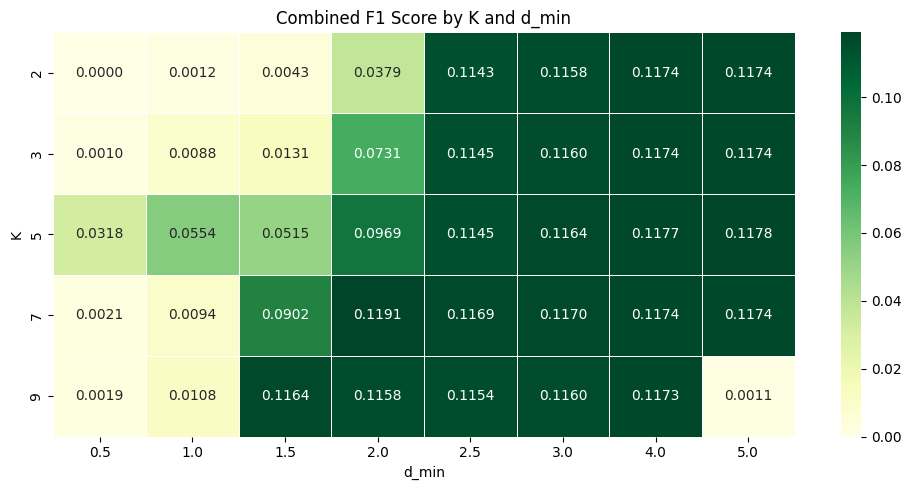

In [52]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot_f1,
    annot=True,
    fmt=".4f",
    cmap="YlGn",
    linewidths=0.5,
    ax=ax
)
ax.set_title("Combined F1 Score by K and d_min")
ax.set_xlabel("d_min")
ax.set_ylabel("K")
plt.tight_layout()
plt.savefig(f"{save_dir}/f1_heatmap.png", dpi=300)
plt.show()

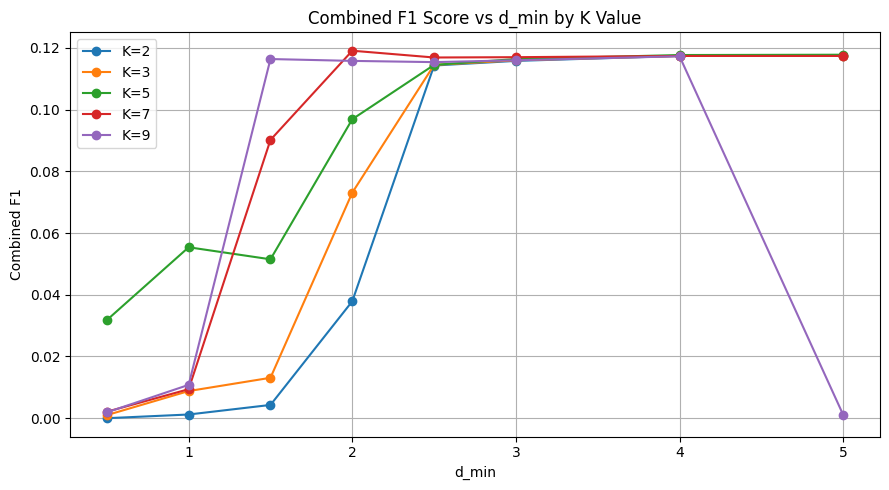

In [53]:
fig, ax = plt.subplots(figsize=(9, 5))

for k in sweep_df["K"].unique():
    subset = sweep_df[sweep_df["K"] == k]
    ax.plot(subset["d_min"], subset["F1"],
            marker="o", label=f"K={k}")

ax.set_xlabel("d_min")
ax.set_ylabel("Combined F1")
ax.set_title("Combined F1 Score vs d_min by K Value")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(f"{save_dir}/f1_by_k.png", dpi=300)
plt.show()